# Análise de Fármacos contra o HIV

Neste notebook, vamos analisar um dataset de descritores moleculares de fármacos, com o objetivo de classificar a sua atividade contra o HIV, isto é, se o uso do medicamento implica o combate contra a doença. Iremos explorar os dados, visualizá-los e treinar modelos de Machine Learning para prever a atividade dos fármacos.

## 1. Importação de Bibliotecas

Começamos por importar a biblioteca `pandas` para manipulação de dados.

In [2]:
import pandas as pd

## 2. Carregamento e Exploração dos Dados

Carregamos o ficheiro `hiv_balanced_descriptors.csv` e removemos as colunas `Drug_ID` e `SMILES`, que não são relevantes para a modelação numérica. De seguida, visualizamos as primeiras linhas e estatísticas descritivas do dataset.

In [3]:
df = pd.read_csv(open('hiv_balanced_descriptors.csv',mode='r'))
df = df.drop(['Drug_ID','SMILES'],axis=1)
df.head()

df.describe()


,MolLogP,MolWt,TPSA,NumRings,NumAtoms,NumBonds,NumHeavyAtoms,NumHBD,NumHBA,Activity
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,3.342336,432.512930,107.980660,3.424000,29.548500,31.791500,29.548500,2.17150,6.237000,0.500000
std,2.794198,249.147518,95.254809,2.066485,16.808269,18.048571,16.808269,2.69067,4.569494,0.500125
min,-10.322080,90.034000,0.000000,0.000000,4.000000,3.000000,4.000000,0.00000,0.000000,0.000000
25%,1.820245,284.013250,52.600000,2.000000,20.000000,21.000000,20.000000,0.00000,4.000000,0.000000
50%,3.166700,361.630000,82.140000,3.000000,25.000000,27.000000,25.000000,1.00000,5.000000,0.500000
75%,4.619590,496.982250,129.545000,4.000000,34.000000,37.000000,34.000000,3.00000,7.000000,1.000000
max,19.447600,3411.450000,1255.560000,28.000000,222.000000,234.000000,222.000000,27.00000,66.000000,1.000000


## 3. Visualização - Pair Plot

Geramos um **pair plot** para visualizar as relações entre pares de variáveis, colorindo os pontos pela coluna `Activity`. Isto permite-nos observar como as diferentes classes se distribuem no espaço das features.

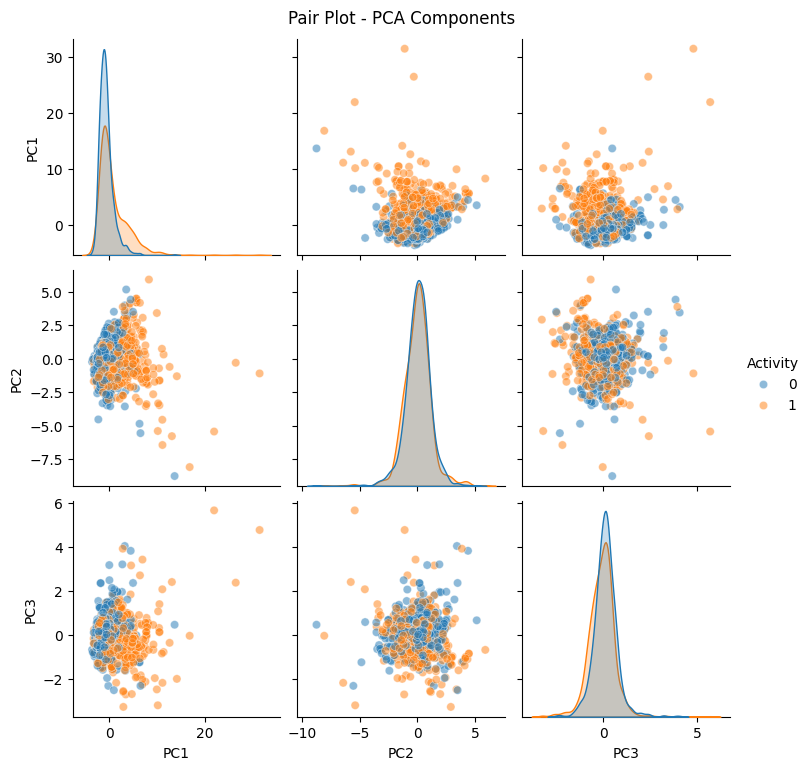

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

numerical_cols = ['MolLogP','MolWt','TPSA','NumRings','NumAtoms','NumBonds','NumHeavyAtoms','NumHBD','NumHBA']
activity = numerical_cols + ['Activity']

X_scaled = StandardScaler().fit_transform(df[numerical_cols])
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
pca_df['Activity'] = df['Activity'].values

sns.pairplot(pca_df, hue='Activity', diag_kind='kde',plot_kws=dict(alpha=0.5))
plt.suptitle('Pair Plot - PCA Components', y=1.02)
plt.show()

## 4. Distribuição das Variáveis Numéricas

Criamos **histogramas** com curvas de densidade (KDE) para cada variável numérica do dataset. Isto ajuda a compreender a distribuição individual de cada feature (e.g., `MolLogP`, `MolWt`, `TPSA`, etc.).

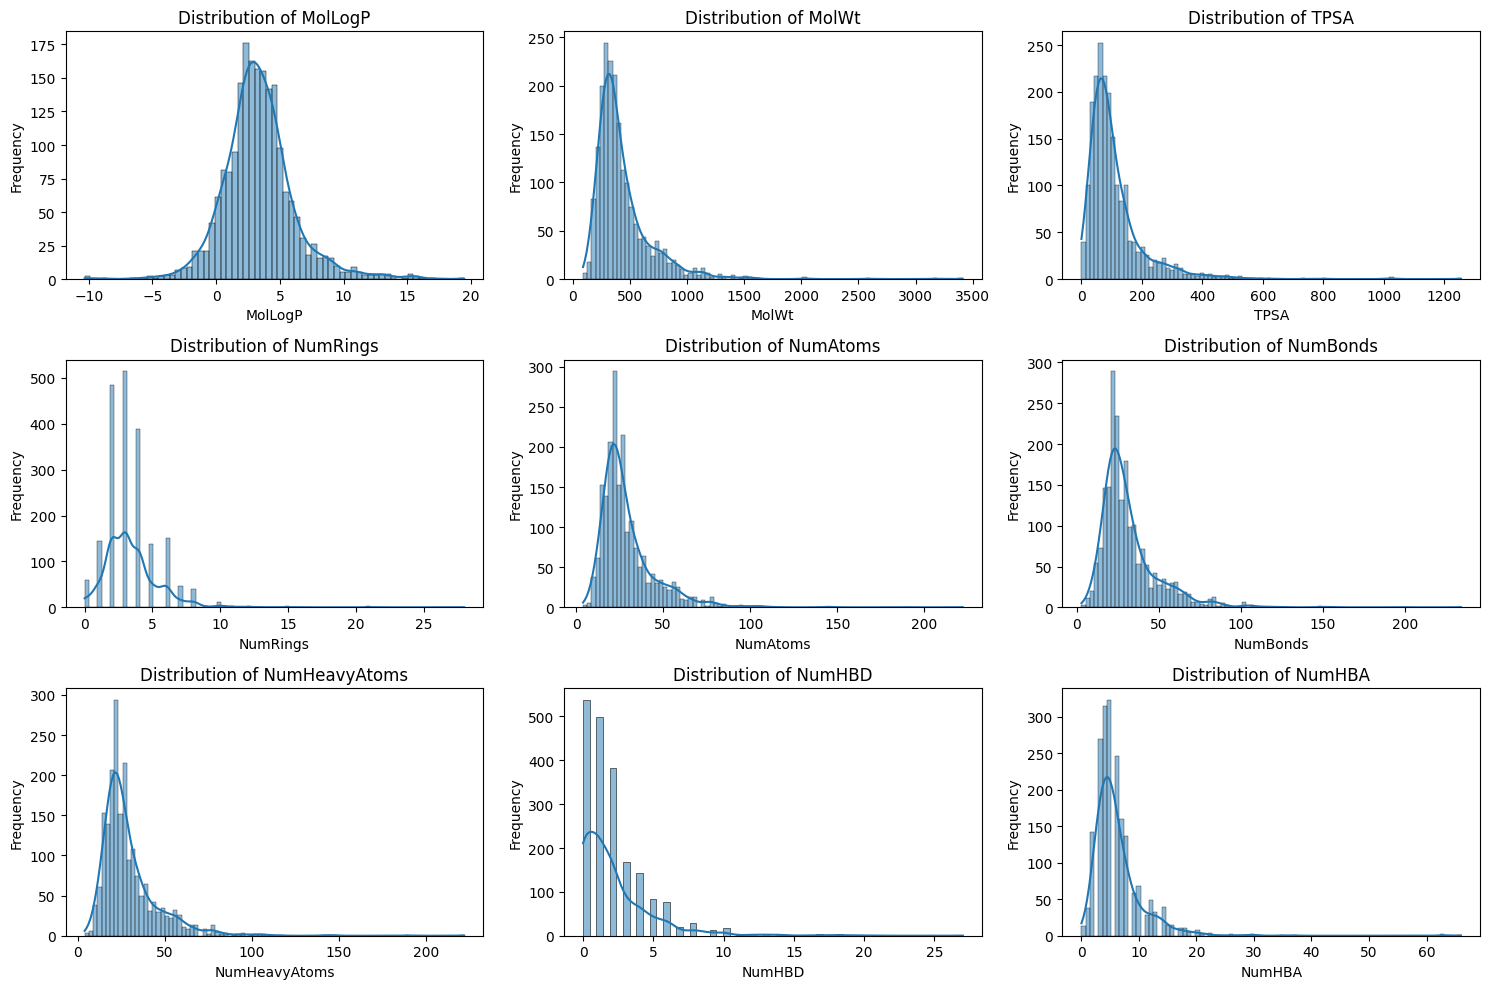

In [5]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Arrange plots in a 3x3 grid
    sns.histplot(df[col], kde=True) # Use histplot for distribution
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## 5. Distribuição da Variável Alvo

Visualizamos a proporção das classes (`Activity`) através de um **gráfico circular (pie chart)**. O dataset é balanceado, o que é importante para evitar viés nos modelos de classificação.

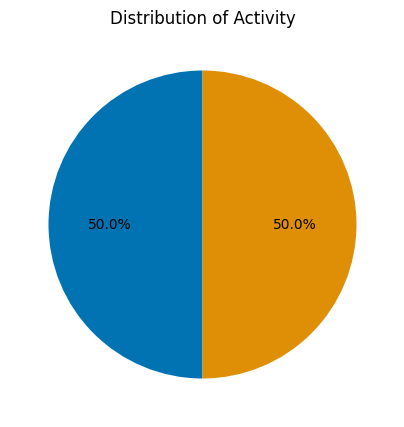

In [6]:
plt.figure(figsize=(5, 5))

colors = sns.color_palette('colorblind')

plt.pie(df['Activity'].value_counts(), autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Distribution of Activity')
plt.show()

## 6. Matriz de Correlação

Apresentamos um **heatmap** da matriz de correlação entre as variáveis numéricas e a variável alvo. Permite identificar quais features estão mais correlacionadas entre si e com a atividade contra o HIV.

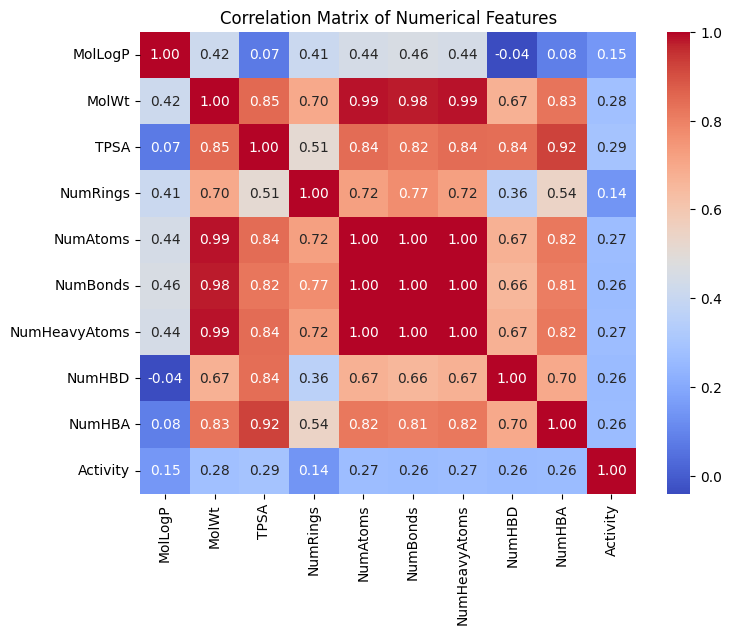

In [7]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[activity].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## 7. Divisão dos Dados e Normalização

Dividimos o dataset em **treino (80%)** e **teste (20%)** com estratificação pela variável alvo para manter a proporção das classes. Aplicamos o `StandardScaler` para normalizar os dados de treino (média 0, desvio padrão 1).

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[numerical_cols]
y = df['Activity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42,
                                                    stratify=y,
                                                    shuffle=True)

print("Data splitting complete.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nApplying StandardScaler to training data...")
# Instantiate a StandardScaler object
scaler = StandardScaler()

# Fit the scaler to the X_train data and transform X_train
X_train_scaled = scaler.fit_transform(X_train)

print("Scaling of training data complete.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")

Data splitting complete.
X_train shape: (1600, 9)
X_test shape: (400, 9)
y_train shape: (1600,)
y_test shape: (400,)

Applying StandardScaler to training data...
Scaling of training data complete.
X_train_scaled shape: (1600, 9)


Verificação rápida dos tipos de dados resultantes do scaling e do target.

In [9]:
type(X_train_scaled), type(y_train)

(numpy.ndarray, pandas.core.series.Series)

## 8. Nested Cross-Validation com Pipelines

Implementamos **Nested Cross-Validation** para comparar dois modelos:
- **K-Nearest Neighbors (KNN)** — com tuning de `n_neighbors`, `weights` e `metric`
- **Gaussian Naive Bayes (NB)** — com tuning de `var_smoothing`

Utilizamos **Pipelines** (com `StandardScaler` integrado) para evitar *data leakage*. O ciclo externo (5 folds) avalia o desempenho generalizável, enquanto o ciclo interno (3 folds) otimiza os hiperparâmetros via `GridSearchCV`.

In [10]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

print("Starting Nested Cross-Validation with Pipeline...")

# 3. Define the parameter grid for K-Nearest Neighbors (KNN)
# Note: parameters prefixed with 'knn__' because 'knn' is a step in the pipeline
knn_param_grid = {
    'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 15],
    'knn__weights': ['uniform', 'distance'], 
    'knn__metric': ['euclidean', 'manhattan']
}

# 4. Define the parameter grid for Gaussian Naive Bayes (NB)
# Note: parameters prefixed with 'nb__' because 'nb' is a step in the pipeline
nb_param_grid = {
    'nb__var_smoothing': np.logspace(start=0, stop=-9, num=100, base=10)
}

# 5. Initialize an outer_cv object using StratifiedKFold
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 6. Initialize empty lists to store the cross-validation scores
knn_outer_scores = []
nb_outer_scores = []

# 7. Loop through the outer folds (data is NOT pre-scaled)
for train_idx, test_idx in outer_cv.split(X_train, y_train):
    X_outer_train, X_outer_test = X_train.iloc[train_idx], X_train.iloc[test_idx]
    y_outer_train, y_outer_test = y_train.iloc[train_idx], y_train.iloc[test_idx]

    # a. Inside the loop, define an inner_cv object
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    # b. For KNN with Pipeline:
    # i. Create a Pipeline with StandardScaler and KNeighborsClassifier
    knn_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier())
    ])
    # ii. Create a GridSearchCV object with the pipeline
    knn_grid_search = GridSearchCV(knn_pipeline, knn_param_grid, cv=inner_cv, scoring='accuracy')
    # iii. Fit the GridSearchCV object on the outer training fold
    knn_grid_search.fit(X_outer_train, y_outer_train)
    # iv. Evaluate the best_estimator_ on the outer test fold
    knn_best_model = knn_grid_search.best_estimator_
    knn_pred = knn_best_model.predict(X_outer_test)
    knn_outer_scores.append(accuracy_score(y_outer_test, knn_pred))

    # c. For Naive Bayes with Pipeline:
    # i. Create a Pipeline with StandardScaler and GaussianNB
    nb_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('nb', GaussianNB())
    ])
    # ii. Create a GridSearchCV object with the pipeline
    nb_grid_search = GridSearchCV(nb_pipeline, nb_param_grid, cv=inner_cv, scoring='accuracy')
    # iii. Fit the GridSearchCV object on the outer training fold
    nb_grid_search.fit(X_outer_train, y_outer_train)
    # iv. Evaluate the best_estimator_ on the outer test fold
    nb_best_model = nb_grid_search.best_estimator_
    nb_pred = nb_best_model.predict(X_outer_test)
    nb_outer_scores.append(accuracy_score(y_outer_test, nb_pred))

# 8. Print the mean and standard deviation of the cross-validation scores
print("\nNested Cross-Validation Results with Pipeline:")
print(f"KNN - Mean Accuracy: {np.mean(knn_outer_scores):.4f} (+/- {np.std(knn_outer_scores):.4f})")
print(f"Naive Bayes - Mean Accuracy: {np.mean(nb_outer_scores):.4f} (+/- {np.std(nb_outer_scores):.4f})")

Starting Nested Cross-Validation with Pipeline...

Nested Cross-Validation Results with Pipeline:
KNN - Mean Accuracy: 0.6619 (+/- 0.0191)
Naive Bayes - Mean Accuracy: 0.6038 (+/- 0.0162)


## 9. Treino Final dos Modelos

Após a Nested CV, re-treinamos ambos os modelos (**KNN** e **Naive Bayes**) no conjunto completo de treino usando `GridSearchCV` para encontrar os melhores hiperparâmetros finais. Os pipelines garantem que o scaling é aplicado corretamente.

In [11]:
# Re-run GridSearchCV for Naive Bayes on the entire X_train and y_train dataset
print("Training best Naive Bayes model with Pipeline...")
nb_pipeline_final = Pipeline([
    ('scaler', StandardScaler()),
    ('nb', GaussianNB())
])
nb_grid_search_final = GridSearchCV(nb_pipeline_final, nb_param_grid, cv=inner_cv, scoring='accuracy')
nb_grid_search_final.fit(X_train, y_train)
best_nb_model = nb_grid_search_final.best_estimator_
print(f"Best NB parameters: {nb_grid_search_final.best_params_}")
print(f"Best NB accuracy: {nb_grid_search_final.best_score_:.4f}")

# Re-run GridSearchCV for KNN on the entire X_train and y_train dataset
print("\nTraining best KNN model with Pipeline...")
knn_pipeline_final = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
knn_grid_search_final = GridSearchCV(knn_pipeline_final, knn_param_grid, cv=inner_cv, scoring='accuracy')
knn_grid_search_final.fit(X_train, y_train)
best_knn_model = knn_grid_search_final.best_estimator_
print(f"Best KNN parameters: {knn_grid_search_final.best_params_}")
print(f"Best KNN accuracy: {knn_grid_search_final.best_score_:.4f}")

Training best Naive Bayes model with Pipeline...
Best NB parameters: {'nb__var_smoothing': np.float64(0.1873817422860384)}
Best NB accuracy: 0.6069

Training best KNN model with Pipeline...
Best KNN parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 11, 'knn__weights': 'distance'}
Best KNN accuracy: 0.6719


## 10. Avaliação Final no Conjunto de Teste

Avaliamos os melhores modelos treinados no **conjunto de teste** (nunca visto durante o treino). Apresentamos a **accuracy**, o **classification report** (precision, recall, F1-score) e a **confusion matrix** para cada modelo, seguidos de uma comparação direta.

In [12]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print("\n" + "="*60)
print("FINAL EVALUATION ON TEST SET")
print("="*60)

# IMPORTANT: Make predictions directly with pipeline (no pre-scaling needed!)
# The pipeline contains its own scaler fitted during training

# KNN predictions
print("\n🔵 KNN Model Predictions:")
knn_pred_test = best_knn_model.predict(X_test)  # X_test NOT scaled
knn_accuracy = accuracy_score(y_test, knn_pred_test)
print(f"KNN Test Set Accuracy: {knn_accuracy:.4f}")
print("\nKNN Classification Report:")
print(classification_report(y_test, knn_pred_test))
print("KNN Confusion Matrix:")
print(confusion_matrix(y_test, knn_pred_test))

# Naive Bayes predictions
print("\n🟡 Naive Bayes Model Predictions:")
nb_pred_test = best_nb_model.predict(X_test)  # X_test NOT scaled
nb_accuracy = accuracy_score(y_test, nb_pred_test)
print(f"Naive Bayes Test Set Accuracy: {nb_accuracy:.4f}")
print("\nNaive Bayes Classification Report:")
print(classification_report(y_test, nb_pred_test))
print("Naive Bayes Confusion Matrix:")
print(confusion_matrix(y_test, nb_pred_test))

# Comparison
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(f"KNN Accuracy:          {knn_accuracy:.4f}")
print(f"Naive Bayes Accuracy:  {nb_accuracy:.4f}")
print(f"Better Model:          {'KNN' if knn_accuracy > nb_accuracy else 'Naive Bayes'}")


FINAL EVALUATION ON TEST SET

🔵 KNN Model Predictions:
KNN Test Set Accuracy: 0.6600

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.61      0.64       200
           1       0.65      0.70      0.67       200

    accuracy                           0.66       400
   macro avg       0.66      0.66      0.66       400
weighted avg       0.66      0.66      0.66       400

KNN Confusion Matrix:
[[123  77]
 [ 59 141]]

🟡 Naive Bayes Model Predictions:
Naive Bayes Test Set Accuracy: 0.6125

Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.94      0.71       200
           1       0.83      0.28      0.42       200

    accuracy                           0.61       400
   macro avg       0.70      0.61      0.57       400
weighted avg       0.70      0.61      0.57       400

Naive Bayes Confusion Matrix:
[[188  12]
 [143  57]]

MODEL COMPARISON
KNN Accu

## 11. Visualização da Confusion Matrix

Visualizamos graficamente a **confusion matrix** do modelo KNN no conjunto de teste, para uma análise mais intuitiva dos erros de classificação (falsos positivos vs falsos negativos).


Confusion Matrix for KNN on Scaled Test Set:


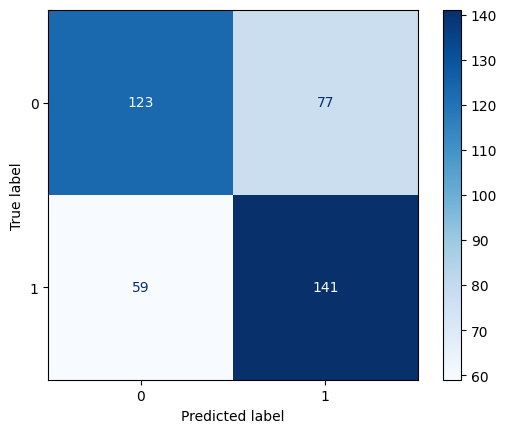

In [13]:
#plot confusion matrix of KNN
from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt

#display
print("\nConfusion Matrix for KNN on Scaled Test Set:")
knn_cm = ConfusionMatrixDisplay.from_predictions(y_test, knn_pred_test, display_labels=best_knn_model.classes_, cmap='Blues')